# Conclusion

This analysis examined mutual fund industry trends between 2022 and 2025.

Key observations include:

- Strong NAV appreciation across most schemes.
- Record SIP inflows reaching ₹31,002 crore.
- Significant growth in industry folio counts.
- Dominance of large fund houses such as SBI Mutual Fund.
- Continued retail participation through SIP investments.
- High portfolio concentration in Financials and Technology sectors.

The results indicate sustained growth and increasing investor participation in the Indian mutual fund industry.

### Insight 10

A small number of sectors account for a large proportion of invested capital.

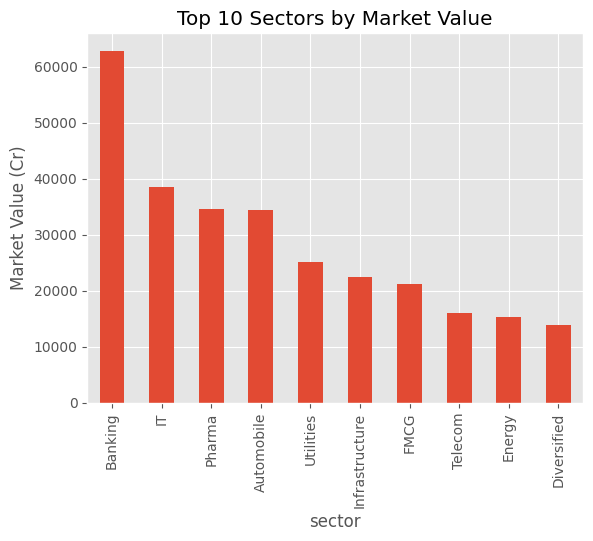

In [33]:
top_sectors = (
    portfolio
    .groupby("sector")
    ["market_value_cr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sectors.plot(
    kind="bar"
)

plt.title(
    "Top 10 Sectors by Market Value"
)

plt.ylabel("Market Value (Cr)")

plt.savefig(
    "../reports/charts/top_sectors.png"
)

plt.show()

### Insight 9

SIP-linked assets under management increased significantly over the four-year period.

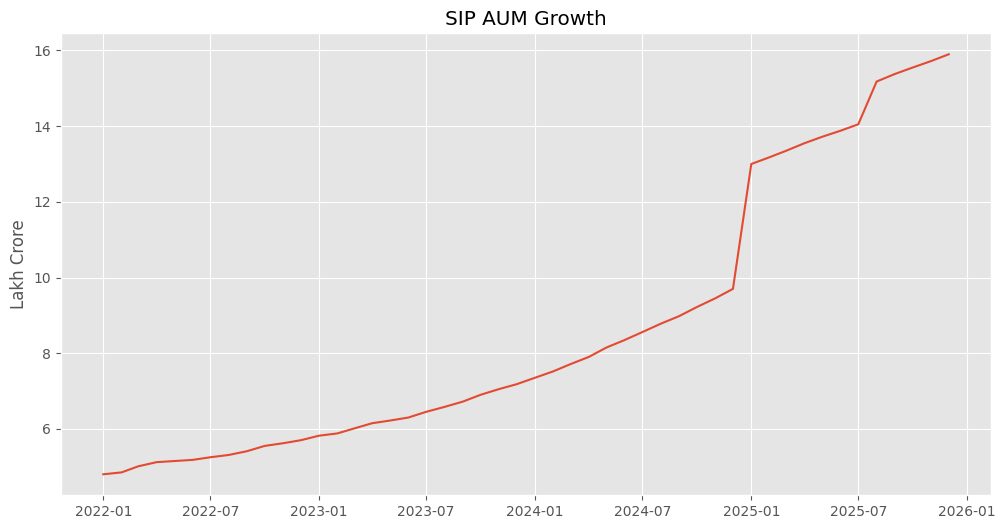

In [34]:
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_aum_lakh_crore"]
)

plt.title(
    "SIP AUM Growth"
)

plt.ylabel("Lakh Crore")

plt.savefig(
    "../reports/charts/sip_aum_growth.png"
)

plt.show()

### Insight 8

Monthly SIP registrations remained strong, indicating continued investor acquisition.

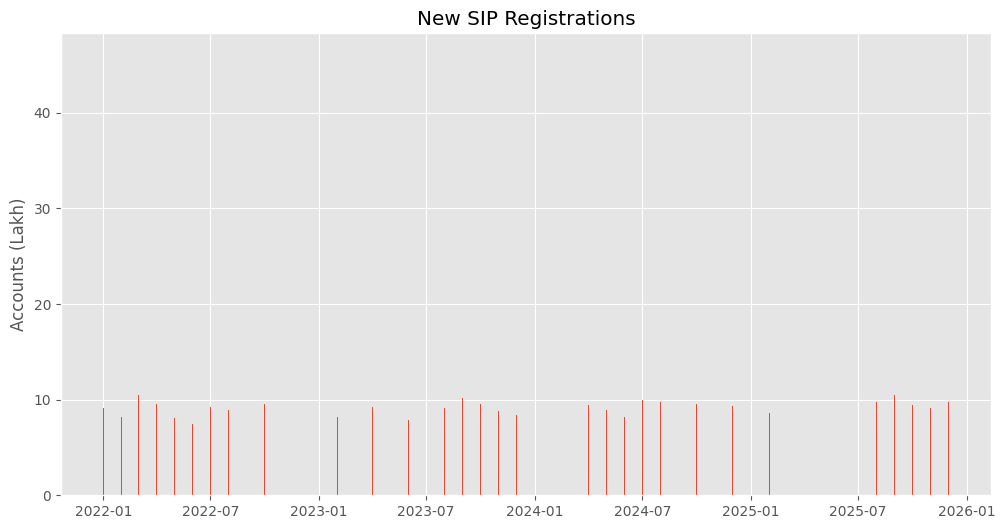

In [35]:
plt.figure(figsize=(12,6))

plt.bar(
    sip["month"],
    sip["new_sip_accounts_lakh"]
)

plt.title(
    "New SIP Registrations"
)

plt.ylabel("Accounts (Lakh)")

plt.savefig(
    "../reports/charts/new_sip_accounts.png"
)

plt.show()

### Insight 7

The number of active SIP accounts increased steadily throughout the study period.

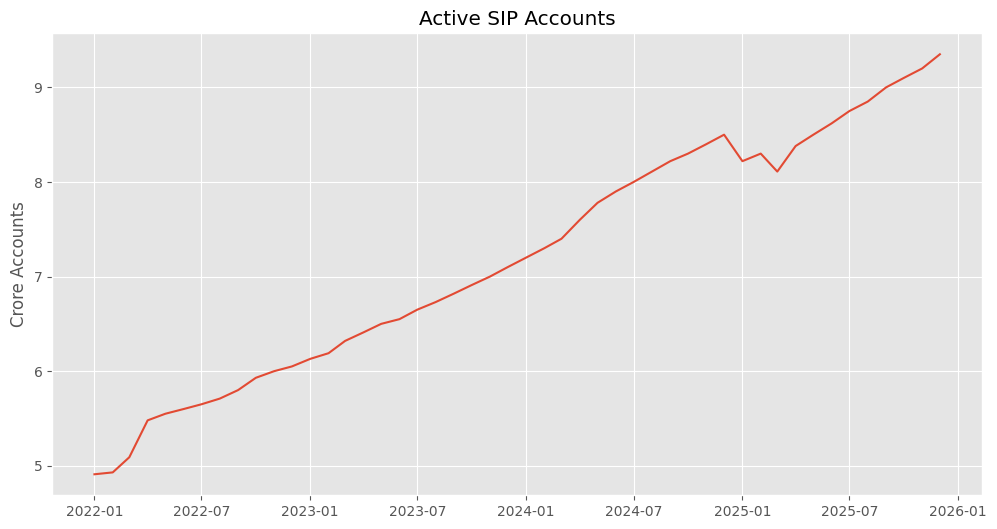

In [36]:
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["active_sip_accounts_crore"]
)

plt.title(
    "Active SIP Accounts"
)

plt.ylabel("Crore Accounts")

plt.savefig(
    "../reports/charts/active_sip_accounts.png"
)

plt.show()

### Insight 6

Financials and Technology sectors represented the largest portfolio allocations across equity funds.

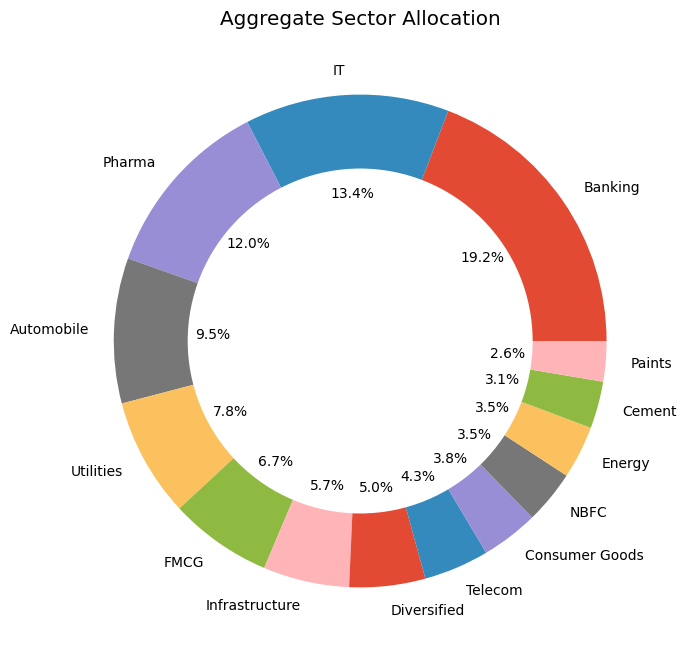

In [37]:
sector_alloc = (
    portfolio
    .groupby("sector")
    ["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_alloc,
    labels=sector_alloc.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title(
    "Aggregate Sector Allocation"
)

plt.savefig(
    "../reports/charts/sector_allocation.png"
)

plt.show()

### Insight 5

Industry folio counts nearly doubled between 2022 and 2025, highlighting strong retail participation growth.

# Sector Allocation Analysis

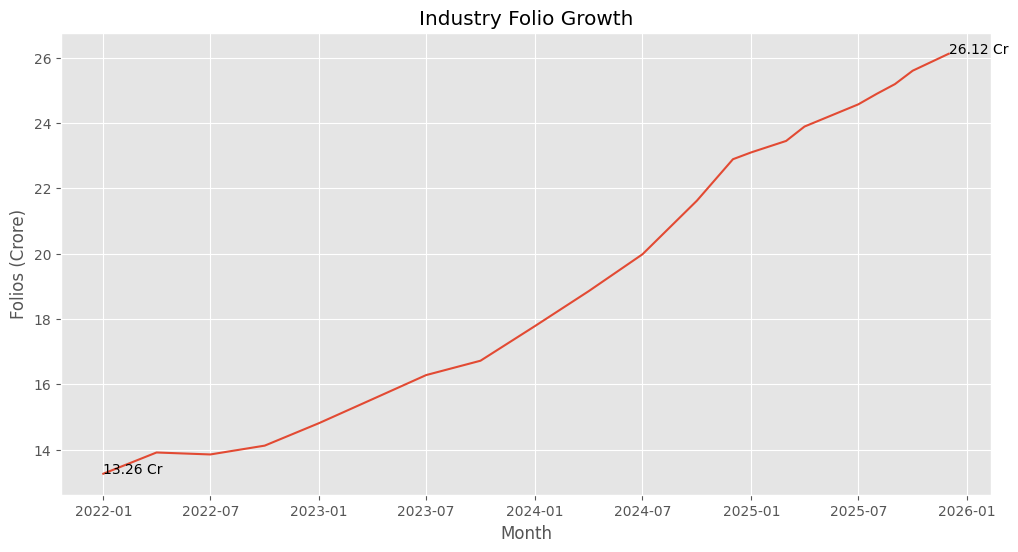

In [19]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title(
    "Industry Folio Growth"
)

plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.annotate(
    "13.26 Cr",
    xy=(
        folio["month"].iloc[0],
        folio["total_folios_crore"].iloc[0]
    )
)

plt.annotate(
    "26.12 Cr",
    xy=(
        folio["month"].iloc[-1],
        folio["total_folios_crore"].iloc[-1]
    )
)

plt.savefig(
    "../reports/charts/folio_growth.png"
)

plt.show()

### Insight 4

Equity-oriented categories consistently attracted stronger inflows compared with debt-oriented categories.

# Industry Folio Growth

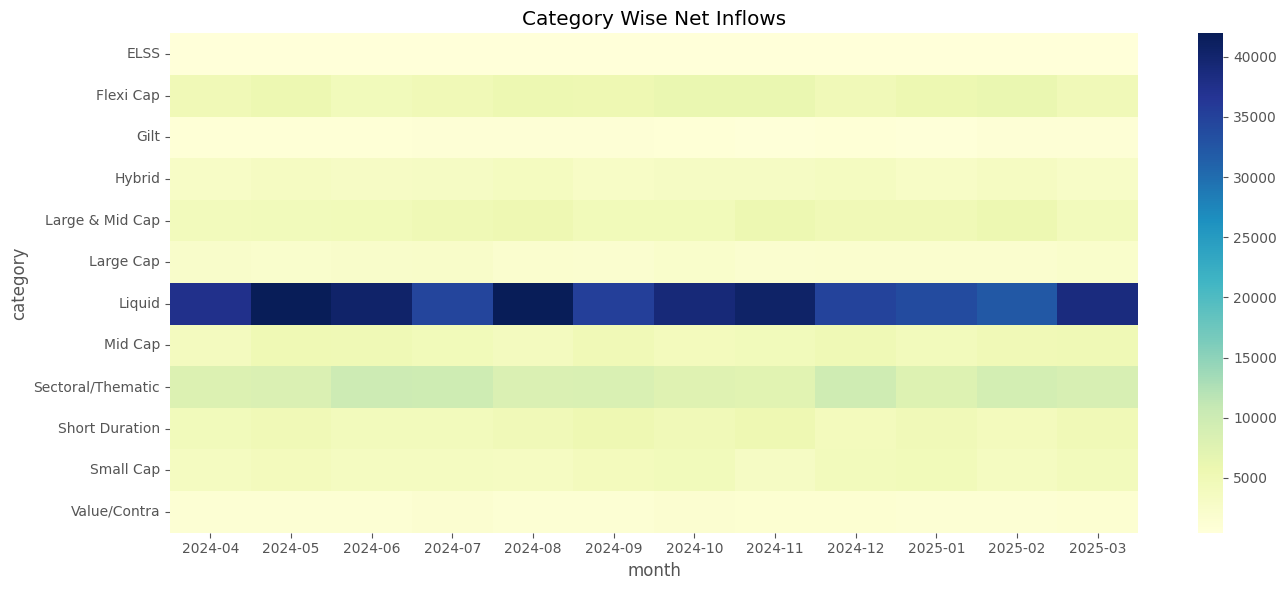

In [17]:
heatmap_df = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu"
)

plt.title("Category Wise Net Inflows")
plt.tight_layout()

plt.savefig(
    "../reports/charts/category_heatmap.png"
)

plt.show()

### Insight 3

SIP inflows showed a consistent upward trajectory and reached a record high of ₹31,002 crore by the end of 2025.
# Category Wise Inflows

In [12]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)"
)

fig.add_annotation(
    x=sip["month"].max(),
    y=sip["sip_inflow_crore"].max(),
    text="₹31,002 Cr All-Time High",
    showarrow=True
)

fig.show()

In [13]:
# SIP Inflow Trend Analysis

In [14]:
print("SIP")
print(sip.columns.tolist())

print("\nCategory")
print(category.columns.tolist())

print("\nFolio")
print(folio.columns.tolist())

print("\nPortfolio")
print(portfolio.columns.tolist())

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category
['month', 'category', 'net_inflow_crore']

Folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Portfolio
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [15]:
fig.write_html(
    "../reports/charts/nav_trend.html"
)

fig.write_image(
    "../reports/charts/nav_trend.png"
)

Resorting to unclean kill browser.


TypeError: Type is not JSON serializable: Timestamp

### Insight 1

Most mutual funds experienced a strong upward NAV trend,
particularly during the 2023 market rally.

Now save the chart created.

In [ ]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2025)"
)

fig.show()

# Nav Trend Analysis

In [5]:
fund = pd.read_csv("../data/processed/fund_master_clean.csv")

nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

txn = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

perf = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

aum = pd.read_csv(
    "../data/processed/aum_by_fund_house_clean.csv"
)

sip = pd.read_csv(
    "../data/processed/monthly_sip_inflows_clean.csv"
)

category = pd.read_csv(
    "../data/processed/category_inflows_clean.csv"
)

folio = pd.read_csv(
    "../data/processed/industry_folio_count_clean.csv"
)

portfolio = pd.read_csv(
    "../data/processed/portfolio_holdings_clean.csv"
)

print("Data Loaded")

Data Loaded


# load dataset

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

print("Libraries Loaded")

Libraries Loaded


# Mutual Fund Analytics Project
## Exploratory Data Analysis (EDA)

Author: Anjali Prakash

This notebook analyzes NAV trends, AUM growth, SIP inflows,
investor demographics, category inflows, portfolio allocations,
and fund performance from 2022–2025.